<a href="https://colab.research.google.com/github/hardik-xi11/colab-notebooks-bckp/blob/main/india-air-weather-quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
filename = 'indian_weather_data.csv'

try:
    df = pd.read_csv(filename)
    print(f"✅ Successfully loaded '{filename}'")
    print(f"📊 Dataset contains {df.shape[0]} cities and {df.shape[1]} columns.")
    display(df.head(3))
except FileNotFoundError:
    print("❌ Error: File not found. Please upload 'indian_weather_data.csv' to the Files tab on the left.")

✅ Successfully loaded 'indian_weather_data.csv'
📊 Dataset contains 74 cities and 25 columns.


,city,lat,lon,temperature,weather_code,sunrise,sunset,moonrise,moonset,co,...,wind_speed,wind_degree,wind_dir,pressure,precip,humidity,cloudcover,feelslike,uv_index,visibility
0,New Delhi,28.600,77.200,21,143,07:05 AM,05:26 PM,01:04 AM,01:06 PM,1411.85,...,4,34,NE,1017,0.0,53,50,21,0,1
1,Mumbai,18.975,72.826,30,122,07:03 AM,06:03 PM,01:20 AM,01:29 PM,644.85,...,18,300,WNW,1011,0.0,35,0,32,0,4
2,Kolkata,22.570,88.370,21,143,06:07 AM,04:54 PM,12:16 AM,12:23 PM,457.85,...,8,3,N,1014,0.0,73,0,21,0,3


In [6]:
# 1. Select Features (X) and Target (y)
# We use atmospheric data to predict Temperature
feature_cols = [
    'lat', 'lon',         # Location
    'pressure',           # Atmospheric Pressure (Strong predictor!)
    'humidity',           # Moisture
    'wind_speed',         # Wind
    'cloudcover',         # Cloudiness
    'pm2_5', 'pm10'       # Pollution levels (sometimes related to heat)
]

target_col = 'temperature'

# 2. Create X and y matrices
X = df[feature_cols]
y = df[target_col]

# 3. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data prepared.")
print(f"Training on {len(X_train)} cities, Testing on {len(X_test)} cities.")

✅ Data prepared.
Training on 59 cities, Testing on 15 cities.


In [7]:
# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
print("⚙️ Training the AI model...")
model.fit(X_train, y_train)
print("✅ Training complete!")

⚙️ Training the AI model...
✅ Training complete!


--- Model Performance ---
📉 Mean Squared Error: 4.06
⭐ R² Score (Accuracy): 0.7558


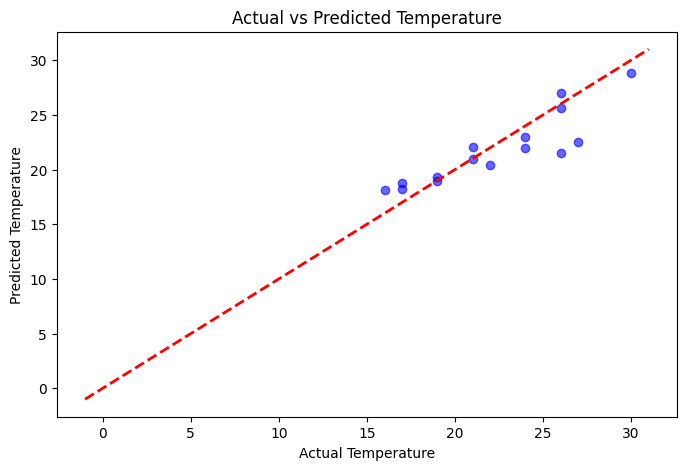

In [8]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate Accuracy Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance ---")
print(f"📉 Mean Squared Error: {mse:.2f}")
print(f"⭐ R² Score (Accuracy): {r2:.4f}")

# Visualize the results
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()

In [10]:
def predict_weather(lat, lon, pressure, humidity, wind, clouds, pm25, pm10):
    # Organize input into a DataFrame
    input_data = pd.DataFrame({
        'lat': [lat],
        'lon': [lon],
        'pressure': [pressure],
        'humidity': [humidity],
        'wind_speed': [wind],
        'cloudcover': [clouds],
        'pm2_5': [pm25],
        'pm10': [pm10]
    })

    # Predict
    prediction = model.predict(input_data)[0]
    return prediction

# --- TEST YOUR OWN VALUES HERE ---
# Try changing 'pressure' or 'humidity' to see how temp changes!
# Note: Lower pressure often correlates with higher storms/temp changes.
my_weather_scenario = {
    'lat': 28.6,       # Like New Delhi
    'lon': 77.2,
    'pressure': 1005,  # Standard is ~1013. Lower is often stormier/hotter.
    'humidity': 40,    # %
    'wind': 15,        # km/h
    'clouds': 10,      # %
    'pm25': 150,       # Pollution
    'pm10': 200
}

predicted_temp = predict_weather(
    my_weather_scenario['lat'], my_weather_scenario['lon'],
    my_weather_scenario['pressure'], my_weather_scenario['humidity'],
    my_weather_scenario['wind'], my_weather_scenario['clouds'],
    my_weather_scenario['pm25'], my_weather_scenario['pm10']
)

print(f"🌤️ Based on these conditions, the predicted temperature is: {predicted_temp:.1f}°C")

🌤️ Based on these conditions, the predicted temperature is: 24.0°C
